In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader
import random
from sklearn.model_selection import train_test_split

# Load dataset
file_path = r"/content/drive/My Drive/bug/software_issues_dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Define the same model structure
class SiameseNetwork(nn.Module):
    def __init__(self, input_dim=384, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = torch.nn.functional.normalize(x, p=2, dim=1)  # L2 normalization
        return x  # Embedding output

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/content/drive/MyDrive/bug/siamese_model2.pth"  # Adjust if needed
siamese_model = SiameseNetwork().to(device)
siamese_model.load_state_dict(torch.load(model_path, map_location=device))
siamese_model.eval()  # Set model to evaluation mode
print("✅ Siamese Model Loaded Successfully!")


<ipython-input-3-3f86678ea3cf>:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  siamese_model.load_state_dict(torch.load(model_path, map_location=device))


✅ Siamese Model Loaded Successfully!


In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Issue Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Issue Category"].astype("category").cat.categories))

# Load trained Siamese model
siamese_model = SiameseNetwork(input_dim=384, embedding_dim=128)
siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))
siamese_model.eval()

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/mlp_model2.pkl")

# Step 1: Convert New Data to Embeddings
new_descriptions = [
    # Performance & Resource Issues
    "Memory usage spikes significantly when processing large XML files, leading to eventual OOM down.",
    "The application experiences severe latency when rendering complex 3D models, making it nearly unusable.",

    # Functionality & Behavior Issues
    "Users report that the 'Auto-Save' feature intermittently fails to save progress, causing data loss.",
    "Clicking the 'Delete Account' button does nothing, but the console logs show a 500 internal server error.",

    # Crash & Failure Issues
    "Pressing the 'Export' button immediately crashes the app with a segmentation fault.",
    "The mobile app crashes after rotating the screen multiple times during video playback.",

    # Build & Compilation Issues
    "Compilation fails with an obscure 'undefined symbol' error, but only on macOS builds.",
    "The CI/CD pipeline randomly fails due to a 'missing dependency', even though it exists in local builds.",

    # UI & Display Issues
    "Dropdown menus overlap with other elements, making options impossible to select.",
    "Icons appear distorted and unreadable on high-DPI screens, breaking usability on 4K monitors.",

    # Combined Issues (to test complexity)
    "The app not only fails to load large datasets but also crashes if the user tries to switch views rapidly.",
    "Text input fields don't register keystrokes on mobile devices, but work fine on desktops."
]

print("\nRaw Descriptions:")
for desc in new_descriptions:
    print(f"- {desc}")

# Encode using SBERT
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)
print("\nSBERT Embeddings:")
print(new_embeddings)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

print("\nSiamese Network Output:")
print(new_embeddings)

# Step 3: Standardize the Embeddings
scaler = StandardScaler()
new_embeddings = scaler.fit_transform(new_embeddings)  # Use same scaler as training
print("\nStandardized Embeddings:")
print(new_embeddings)

# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)
print("\nMLP Predictions (Label Indices):")
print(predictions)

# Step 5: Convert predictions to category names
predicted_categories = [label_to_category[label] for label in predictions]
print("\nPredicted Categories:")
for desc, category in zip(new_descriptions, predicted_categories):
    print(f"Bug: '{desc}' → Predicted Category: {category}")


<ipython-input-11-74b5fdea83e5>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))



Raw Descriptions:
- Memory usage spikes significantly when processing large XML files, leading to eventual OOM down.
- The application experiences severe latency when rendering complex 3D models, making it nearly unusable.
- Users report that the 'Auto-Save' feature intermittently fails to save progress, causing data loss.
- Clicking the 'Delete Account' button does nothing, but the console logs show a 500 internal server error.
- Pressing the 'Export' button immediately crashes the app with a segmentation fault.
- The mobile app crashes after rotating the screen multiple times during video playback.
- Compilation fails with an obscure 'undefined symbol' error, but only on macOS builds.
- The CI/CD pipeline randomly fails due to a 'missing dependency', even though it exists in local builds.
- Dropdown menus overlap with other elements, making options impossible to select.
- Icons appear distorted and unreadable on high-DPI screens, breaking usability on 4K monitors.
- The app not only

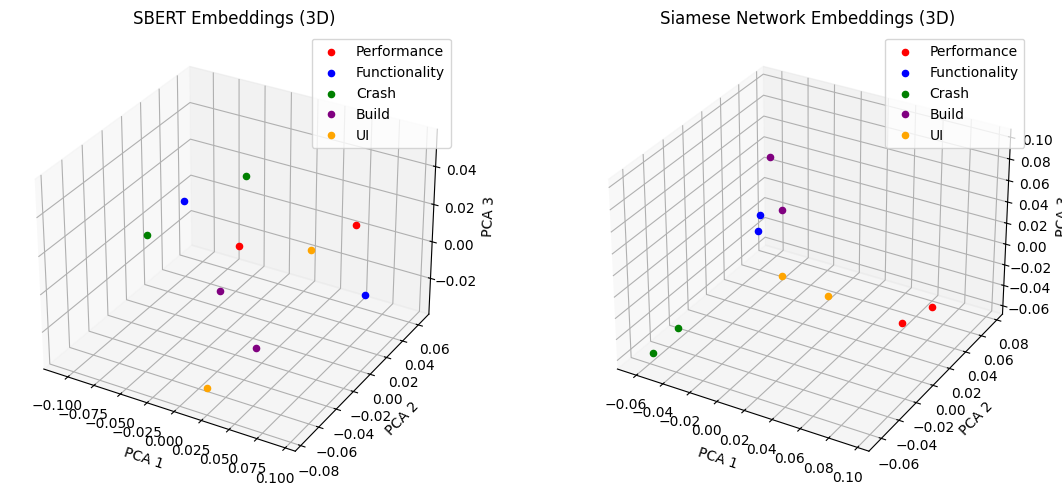

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Sample SBERT Embeddings (First 4 values)
sbert_embeddings = np.array([
    [0.0324, 0.0185, -0.0182, 0.0584],  # Performance
    [0.0034, -0.0547, 0.0044, 0.0238],  # Performance
    [0.0014, 0.0087, -0.0139, 0.0944],  # Functionality
    [0.0092, -0.0401, -0.0077, -0.0591],  # Functionality
    [0.0329, -0.0576, -0.0075, 0.0134],  # Crash
    [0.0083, -0.0251, 0.0488, -0.0958],  # Crash
    [-0.0341, -0.0105, 0.0212, 0.0267],  # Build
    [-0.0146, 0.0080, 0.0205, -0.0432],  # Build
    [-0.0659, -0.0588, 0.0155, 0.0354],  # UI
    [0.0214, 0.0454, 0.0049, -0.0003],  # UI
])

# Sample Siamese Embeddings (First 4 values)
siamese_embeddings = np.array([
    [0.0161, 0.1462, 0.2014, -0.1222],  # Performance
    [0.0311, 0.1599, 0.2008, -0.0981],  # Performance
    [-0.0382, 0.1012, 0.1169, -0.0862],  # Functionality
    [-0.0625, 0.0924, 0.1408, -0.0197],  # Functionality
    [-0.0936, 0.1607, 0.1141, -0.1302],  # Crash
    [-0.1038, 0.1251, 0.1248, -0.1824],  # Crash
    [0.0252, 0.1073, 0.0347, -0.1241],  # Build
    [0.0081, 0.0770, 0.0942, -0.1471],  # Build
    [-0.0044, 0.1423, 0.1517, -0.1321],  # UI
    [-0.0095, 0.1143, 0.1213, -0.1642],  # UI
])

# Corresponding labels (categories)
categories = [
    "Performance", "Performance",
    "Functionality", "Functionality",
    "Crash", "Crash",
    "Build", "Build",
    "UI", "UI"
]

# Convert embeddings to 3D using PCA
pca_sbert = PCA(n_components=3)
pca_siamese = PCA(n_components=3)

sbert_3d = pca_sbert.fit_transform(sbert_embeddings)
siamese_3d = pca_siamese.fit_transform(siamese_embeddings)

# Define colors for categories
colors = {
    "Performance": "red",
    "Functionality": "blue",
    "Crash": "green",
    "Build": "purple",
    "UI": "orange"
}

fig = plt.figure(figsize=(12, 5))

# Plot SBERT Embeddings in 3D
ax1 = fig.add_subplot(121, projection='3d')
for i, category in enumerate(categories):
    ax1.scatter(sbert_3d[i, 0], sbert_3d[i, 1], sbert_3d[i, 2], color=colors[category], label=category if category not in ax1.get_legend_handles_labels()[1] else "")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")
ax1.set_zlabel("PCA 3")
ax1.set_title("SBERT Embeddings (3D)")
ax1.legend()
ax1.grid()

# Plot Siamese Embeddings in 3D
ax2 = fig.add_subplot(122, projection='3d')
for i, category in enumerate(categories):
    ax2.scatter(siamese_3d[i, 0], siamese_3d[i, 1], siamese_3d[i, 2], color=colors[category], label=category if category not in ax2.get_legend_handles_labels()[1] else "")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_zlabel("PCA 3")
ax2.set_title("Siamese Network Embeddings (3D)")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

# Load category mapping
df["Label"] = df["Issue Category"].astype("category").cat.codes  # Ensure this matches training
label_to_category = dict(enumerate(df["Issue Category"].astype("category").cat.categories))

# Load trained Siamese model
siamese_model = SiameseNetwork(input_dim=384, embedding_dim=128)
siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))
siamese_model.eval()

# Load trained MLP model
mlp_model = joblib.load("/content/drive/MyDrive/bug/mlp_model2.pkl")

# Step 1: Convert New Data to Embeddings
new_descriptions = [
    "Thread contention results in slow multi-user performance."
]

print("\nRaw Descriptions:")
for desc in new_descriptions:
    print(f"- {desc}")

# Encode using SBERT
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
new_embeddings = sbert_model.encode(new_descriptions, convert_to_numpy=True)
print("\nSBERT Embeddings:")
print(new_embeddings)

# Step 2: Get Siamese Network Embeddings
with torch.no_grad():
    new_embeddings = torch.tensor(new_embeddings, dtype=torch.float32)
    new_embeddings = siamese_model(new_embeddings).numpy()

print("\nSiamese Network Output:")
print(new_embeddings)


# Step 4: Predict using MLP
predictions = mlp_model.predict(new_embeddings)
print("\nMLP Predictions (Label Indices):")
print(predictions)

# Step 5: Convert predictions to category names
predicted_categories = [label_to_category[label] for label in predictions]
print("\nPredicted Categories:")
for desc, category in zip(new_descriptions, predicted_categories):
    print(f"Bug: '{desc}' → Predicted Category: {category}")


<ipython-input-10-bb0ef5c546c1>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  siamese_model.load_state_dict(torch.load("/content/drive/MyDrive/bug/siamese_model2.pth"))



Raw Descriptions:
- Thread contention results in slow multi-user performance.

SBERT Embeddings:
[[ 5.57847805e-02 -3.51404995e-02 -3.42607847e-03 -4.62440997e-02
  -3.49058695e-02 -8.36826488e-02  2.23551113e-02 -3.44116874e-02
   2.88309269e-02 -1.53023349e-02 -3.06443032e-02 -6.16223505e-03
  -5.00380360e-02 -1.92290656e-02  2.05839761e-02 -1.11939190e-02
   5.89996427e-02 -7.56263211e-02 -4.19911230e-03 -2.82899179e-02
  -4.23640572e-02 -4.87633310e-02 -1.36862565e-02  2.73431670e-02
   4.85173687e-02 -2.19335947e-02 -2.58054137e-02 -3.28304358e-02
  -3.07267103e-02  2.98576485e-02 -9.03211255e-03 -3.93187553e-02
   6.36242563e-03  5.90538839e-03 -5.37662730e-02  2.50617415e-02
  -1.78602096e-02  1.48537674e-03 -2.64155082e-02  1.80882420e-02
  -1.72410533e-02  3.88603024e-02 -2.21030861e-02  2.71010790e-02
  -4.25970703e-02  1.03643676e-02  6.89671887e-03  6.60856953e-04
   4.20093238e-02 -5.81103526e-02 -4.67101745e-02  2.55433340e-02
  -1.52840046e-03 -5.98928779e-02  6.1840120